In [18]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loading model...
Found 1709 images belonging to 4 classes.
Classes: {'bacterial_blight': 0, 'curl_virus': 1, 'fussarium_wilt': 2, 'healthy': 3}
Running GPU predictions...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 575ms/step

✅ Test Accuracy: 97.19%

Classification Report:
                  precision    recall  f1-score   support

bacterial_blight       0.97      0.99      0.98       448
      curl_virus       0.99      0.97      0.98       417
  fussarium_wilt       0.99      0.94      0.96       419
         healthy       0.95      0.99      0.97       425

        accuracy                           0.97      1709
       macro avg       0.97      0.97      0.97      1709
    weighted avg       0.97      0.97      0.97      1709



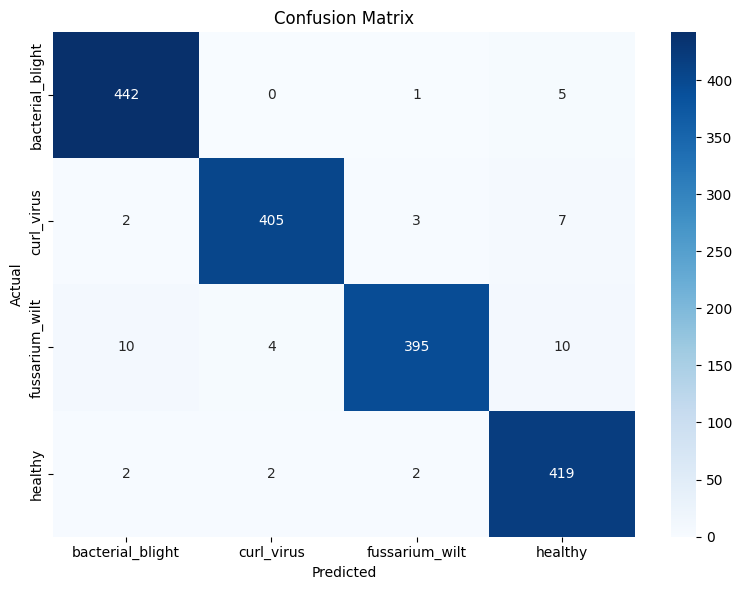


Confusion Matrix saved at:
/content/drive/MyDrive/Datasets/cotton/confusion_matrix.png


In [21]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --------------------------------------------------
# Confirm GPU
# --------------------------------------------------
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# --------------------------------------------------
# PATHS
# --------------------------------------------------
MODEL_PATH = "/content/drive/MyDrive/Datasets/cotton/model_cotton_disease.keras"
DATASET_PATH = "/content/drive/MyDrive/Datasets/cotton"
SAVE_CM_PATH = "/content/drive/MyDrive/Datasets/cotton/confusion_matrix.png"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --------------------------------------------------
# Load Model
# --------------------------------------------------
print("Loading model...")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# --------------------------------------------------
# Create Data Generator (NO augmentation for testing)
# --------------------------------------------------
test_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_data = test_gen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Classes:", test_data.class_indices)

# --------------------------------------------------
# Predict Entire Dataset (GPU Batch Prediction 🚀)
# --------------------------------------------------
print("Running GPU predictions...")
predictions = model.predict(test_data, verbose=1)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

# --------------------------------------------------
# Metrics
# --------------------------------------------------
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc * 100:.2f}%\n")

class_labels = list(test_data.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()

# ✅ Save confusion matrix to Drive
plt.savefig(SAVE_CM_PATH, dpi=300)

plt.show()

print(f"\nConfusion Matrix saved at:\n{SAVE_CM_PATH}")